## Variational Quantum Eigensolver (VQE) for Ground State Energy Estimation of H₂ Molecule
This notebook implements the Variational Quantum Eigensolver (VQE) to estimate the ground-state energy of the hydrogen molecule (H₂) and compare the obtained result with exact classical simulation.

## 1. Schrödinger Equation and the Molecular Hamiltonian

The electronic structure problem is described by the time-independent Schrödinger equation:

$$
\hat{H}\Psi = E\Psi
$$

Where:
- $\hat{H}$ is the molecular Hamiltonian.
- $\Psi$ is the molecular wavefunction.
- $E$ is the total energy eigenvalue.

Under the **Born–Oppenheimer approximation**, the nuclei are assumed to move much more slowly than electrons due to their larger mass. Therefore, the nuclei are treated as fixed while solving the electronic Schrödinger equation.

The molecular electronic Hamiltonian is expressed as:

$$
\hat{H}
=
-\sum_i\frac{\nabla_i^2}{2}
-\sum_{i,A}\frac{Z_A}{r_{iA}}
+\sum_{i<j}\frac{1}{r_{ij}}
+\sum_{A<B}\frac{Z_AZ_B}{R_{AB}}
$$

Where:

Electronic kinetic energy:

$$
-\sum_i\frac{\nabla_i^2}{2}
$$

Electron–nucleus Coulomb attraction:

$$
-\sum_{i,A}\frac{Z_A}{r_{iA}}
$$

Electron–electron Coulomb repulsion:

$$
\sum_{i<j}\frac{1}{r_{ij}}
$$

Nucleus–nucleus Coulomb repulsion:

$$
\sum_{A<B}\frac{Z_AZ_B}{R_{AB}}
$$

Since the nucleus–nucleus repulsion term depends only on the fixed nuclear coordinates under the Born–Oppenheimer approximation, it remains constant during optimization. Therefore, this term is omitted during the VQE calculation and added back later to recover the total molecular energy.

Thus, after removing the constant nucleus–nucleus repulsion term, the electronic Hamiltonian used in VQE becomes:

$$
\hat{H}
=
-\sum_i\frac{\nabla_i^2}{2}
-\sum_{i,A}\frac{Z_A}{r_{iA}}
+\sum_{i<j}\frac{1}{r_{ij}}
$$

In [1]:
# Definition of the Molecule

from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit

# Define the hydrogen molecule (H2)
driver = PySCFDriver(
    atom="H 0 0 0; H 0 0 0.735",
    basis="sto3g",
    charge=0,
    spin=0,
    unit=DistanceUnit.ANGSTROM
)

# Generate the electronic structure problem
problem = driver.run()

print(problem) 

## 2. Second Quantization and Fock Space

In first quantization, a many-electron system is represented using a wavefunction that explicitly depends on the coordinates of all electrons.
For two electrons:
$$
\Psi = \left|x_1\right\rangle \left|x_2\right\rangle
$$
This representation implicitly assumes that electrons can be labeled.
However, electrons are indistinguishable particles, meaning that exchanging two electrons does not change any physical observable.
Therefore:

$$
\left|\Psi(x_1,x_2)\right|^2 = \left|\Psi(x_2,x_1)\right|^2
$$
Thus:

$$
\Psi(x_1,x_2) = \pm \Psi(x_2,x_1)
$$
For Bosons:

$$
\Psi(x_1,x_2) = \Psi(x_2,x_1)
$$
For Fermions:

$$
\Psi(x_1,x_2) = -\Psi(x_2,x_1)
$$
Electrons are Fermions.
Therefore:

$$
\Psi(x_1,x_2) = -\Psi(x_2,x_1)
$$
This gives the Pauli Exclusion Principle.
If two electrons occupy the same state:

$$
\Psi(x,x) = -\Psi(x,x)
$$
Then:
$$
\Psi(x,x)=0
$$
Therefore, two electrons cannot occupy the same quantum state.
For many-electron systems, the electronic wavefunction is represented using the Slater Determinant:

$$
\Psi(x_1,\ldots,x_N) = \frac{1}{\sqrt{N!}}
\begin{vmatrix}
\phi_1(x_1) & \phi_2(x_1) & \cdots & \phi_N(x_1) \\
\phi_1(x_2) & \phi_2(x_2) & \cdots & \phi_N(x_2) \\
\vdots & \vdots & \ddots & \vdots \\
\phi_1(x_N) & \phi_2(x_N) & \cdots & \phi_N(x_N)
\end{vmatrix}
$$
This automatically satisfies Pauli exclusion:

* Swapping two columns changes the sign.
* Identical columns produce:
$$
\Psi=0
$$

---

### Occupation Number Formalism

Instead of explicitly storing the full wavefunction, second quantization uses occupation numbers.
Example:
$$
|1010\rangle
$$
where:
$$
1=\text{occupied} \qquad 0=\text{empty}
$$

**Creation operator:**

$$
a_i^\dagger |n_1\cdots n_i\cdots n_N\rangle = (1-n_i) (-1)^{\sum_{j<i}n_j} |n_1\cdots(n_i+1)\cdots n_N\rangle
$$
where:
$$
n_i=0 \Rightarrow \text{creation}
$$

**Annihilation operator:**

$$
a_i |n_1\cdots n_i\cdots n_N\rangle = n_i (-1)^{\sum_{j<i}n_j} |n_1\cdots(n_i-1)\cdots n_N\rangle
$$
where:
$$
n_i=1 \Rightarrow \text{annihilation}
$$

The factor
$$
(-1)^{\sum_{j<i}n_j}
$$
preserves fermionic antisymmetry.

### The Electronic Hamiltonian in Second Quantization

The electronic Hamiltonian can be rewritten in the second quantized form, where the system is described using creation and annihilation operators acting on Fock space instead of explicitly tracking electron coordinates.
The fermionic Hamiltonian is written as:

$$
\hat{H}_{\mathrm{fermionic}} = \sum_{pq} h_{pq} a_p^\dagger a_q + \frac{1}{2} \sum_{pqrs} h_{pqrs} a_p^\dagger a_q^\dagger a_s a_r
$$
where:

$$
h_{pq} = \int \phi_p^*(x) \left( -\frac{1}{2}\nabla^2 - \sum_A \frac{Z_A}{r_{iA}} \right) \phi_q(x) \, dx
$$
is the **one-electron integral**, representing:
* Electron kinetic energy ($-\frac{1}{2}\nabla^2$)
* Electron–nucleus Coulomb interaction ($-\sum_A \frac{Z_A}{r_{iA}}$)

and

$$
h_{pqrs} = \iint \phi_p^*(x_1) \phi_q^*(x_2) \frac{1}{r_{12}} \phi_r(x_1) \phi_s(x_2) \, dx_1 dx_2
$$
is the **two-electron integral**, representing the electron–electron Coulomb repulsion.


In [2]:

# Extract the fermionic operator

fermionic_op = problem.hamiltonian.second_q_op()

print(fermionic_op)


Fermionic Operator
number spin orbitals=4, number terms=36
  0.33785507740175813 * ( +_0 +_0 -_0 -_0 )
+ 0.3322908651276482 * ( +_0 +_1 -_1 -_0 )
+ 0.33785507740175813 * ( +_0 +_2 -_2 -_0 )
+ 0.3322908651276482 * ( +_0 +_3 -_3 -_0 )
+ 0.09046559989211572 * ( +_0 +_0 -_1 -_1 )
+ 0.09046559989211572 * ( +_0 +_1 -_0 -_1 )
+ 0.09046559989211572 * ( +_0 +_2 -_3 -_1 )
+ 0.09046559989211572 * ( +_0 +_3 -_2 -_1 )
+ 0.09046559989211572 * ( +_1 +_0 -_1 -_0 )
+ 0.09046559989211572 * ( +_1 +_1 -_0 -_0 )
+ 0.09046559989211572 * ( +_1 +_2 -_3 -_0 )
+ 0.09046559989211572 * ( +_1 +_3 -_2 -_0 )
+ 0.3322908651276482 * ( +_1 +_0 -_0 -_1 )
+ 0.34928686136600884 * ( +_1 +_1 -_1 -_1 )
+ 0.3322908651276482 * ( +_1 +_2 -_2 -_1 )
+ 0.34928686136600884 * ( +_1 +_3 -_3 -_1 )
+ 0.33785507740175813 * ( +_2 +_0 -_0 -_2 )
+ 0.3322908651276482 * ( +_2 +_1 -_1 -_2 )
+ 0.33785507740175813 * ( +_2 +_2 -_2 -_2 )
+ 0.3322908651276482 * ( +_2 +_3 -_3 -_2 )
+ 0.09046559989211572 * ( +_2 +_0 -_1 -_3 )
+ 0.09046559989211572 *

## 3. Fermionic to Qubit Mapping

The goal of VQE is to approximate the molecular ground state, which corresponds to the minimum eigenvalue of the Hamiltonian.
The exact ground state is generally not represented by a single configuration but rather as a superposition of many Fock states:

$$
|\Psi_{\mathrm{GS}}\rangle = \sum_{m=1}^{|M|} c_m |m_1 m_2 \cdots\rangle
$$
where:
* $|m_1 m_2 \cdots\rangle$ are occupation-number basis states in Fock space.
* $c_m$ are expansion coefficients.
* $|M|$ is the total number of configurations.

Thus, the true ground state is not a single electronic configuration but a quantum superposition of many configurations.
Since the number of configurations grows exponentially, some orbitals may be treated as **frozen** (always occupied or always empty) to reduce computational cost.
The wavefunction can then be separated as:

$$
|\Psi\rangle = |\Psi_{\mathrm{active}}\rangle \otimes |\Psi_{\mathrm{frozen}}\rangle
$$
Only the **active space** is mapped onto qubits.

---

### The Jordan–Wigner Transformation

To run the problem on a quantum computer, fermionic operators must be transformed into qubit operators (Pauli matrices). 
Using the **Jordan–Wigner (JW) transformation**, the creation operator is mapped as:

$$
a_p^\dagger \rightarrow \left( \prod_{j=0}^{p-1} Z_j \right) \frac{X_p - iY_p}{2}
$$
> **Why the Z-string?** The string of Pauli-$Z$ operators ($\prod_{j=0}^{p-1} Z_j$) computes the parity of all orbitals before orbital $p$, which is crucial for preserving fermionic antisymmetry when particles are exchanged.

Similarly, the annihilation operator is mapped as:
$$
a_p \rightarrow \left( \prod_{j=0}^{p-1} Z_j \right) \frac{X_p + iY_p}{2}
$$

---

### Matrix Representation and Pauli Decomposition

For a single orbital, the creation operator can be written in matrix form as:
$$
a^\dagger = \begin{pmatrix} 0 & 0 \\ 1 & 0 \end{pmatrix}
$$
Since quantum circuits operate using Pauli operators, this matrix is decomposed into a linear combination of Pauli-$X$ and Pauli-$Y$ matrices:
$$
a^\dagger = \frac{X - iY}{2}
$$
and for the annihilation operator:
$$
a = \frac{X + iY}{2}
$$

#### Full Multi-Qubit Representation:
Therefore, when considering the entire register of qubits, the complete Jordan–Wigner creation operator for orbital $p$ becomes:
$$
a_p^\dagger = Z_0 \otimes Z_1 \otimes \cdots \otimes Z_{p-1} \otimes \frac{X_p - iY_p}{2} \otimes I_{p+1} \otimes \cdots
$$

And the annihilation operator becomes:
$$
a_p = Z_0 \otimes Z_1 \otimes \cdots \otimes Z_{p-1} \otimes \frac{X_p + iY_p}{2} \otimes I_{p+1} \otimes \cdots
$$

This transformation successfully converts the fermionic Hamiltonian into a **qubit Hamiltonian** (a sum of Pauli strings) that can be directly executed on a quantum simulator or hardware using VQE.

In [3]:
# Fermionic to Qubit Mapping

from qiskit_nature.second_q.mappers import JordanWignerMapper

# Initialize the mapper
mapper = JordanWignerMapper()

# Map the fermionic Hamiltonian into qubit operators
qubit_hamiltonian = mapper.map(fermionic_op)

# Print the resulting qubit Hamiltonian
print(qubit_hamiltonian)


SparsePauliOp(['IIII', 'IIIZ', 'IIZI', 'IIZZ', 'IZII', 'IZIZ', 'ZIII', 'ZIIZ', 'YYYY', 'XXYY', 'YYXX', 'XXXX', 'IZZI', 'ZIZI', 'ZZII'],
              coeffs=[-0.81054798+0.j,  0.17218393+0.j, -0.22575349+0.j,  0.12091263+0.j,
  0.17218393+0.j,  0.16892754+0.j, -0.22575349+0.j,  0.16614543+0.j,
  0.0452328 +0.j,  0.0452328 +0.j,  0.0452328 +0.j,  0.0452328 +0.j,
  0.16614543+0.j,  0.17464343+0.j,  0.12091263+0.j])


## 4. Hartree–Fock State and Ansatz (Wavefunction)

After obtaining the qubit Hamiltonian, the next objective is to estimate its ground-state energy.
According to the **variational principle**, the energy of any trial state satisfies:

$$
E(\theta) = \frac{\langle\Psi(\theta)| \hat H |\Psi(\theta)\rangle}{\langle\Psi(\theta)|\Psi(\theta)\rangle} \ge E_0
$$
*(Assuming the wavefunction is normalized, this simplifies to: $E(\theta) = \langle\Psi(\theta)| \hat H |\Psi(\theta)\rangle \ge E_0$)*

where:
* $E_0$ is the exact ground-state energy.
* $|\Psi(\theta)\rangle$ is a parameterized trial wavefunction (Ansatz).

---

### The Hartree–Fock (HF) State

The challenge is that the exact ground state is generally unknown and cannot be represented by a single electronic configuration. Therefore, VQE starts from an approximate initial state called the **Hartree–Fock (HF) State**.

The Hartree–Fock state assumes that electrons move independently in an average mean field created by all other electrons. This approximation corresponds to a **single Slater determinant**.
For example, in an occupation-number basis:
$$
|\Psi_{\mathrm{HF}}\rangle = |1100\rangle
$$
meaning:
* First and second orbitals are **occupied** ($1$).
* Third and fourth orbitals are **empty/virtual** ($0$).

However, the true molecular ground state is usually a superposition of many configurations due to electron correlation:
$$
|\Psi_{\mathrm{GS}}\rangle = c_1|1100\rangle + c_2|1010\rangle + c_3|0110\rangle + \cdots
$$

---

### The UCCSD Ansatz

To capture this electron correlation, a more flexible wavefunction must be constructed. This is achieved using an **Ansatz**, which transforms the Hartree–Fock state into a variational quantum state via a unitary operator $U(\theta)$:
$$
|\Psi(\theta)\rangle = U(\theta) |\Psi_{\mathrm{HF}}\rangle
$$

A chemically motivated choice is the **Unitary Coupled Cluster Singles and Doubles (UCCSD)** Ansatz:
$$
|\Psi(\theta)\rangle = e^{\hat T(\theta) - \hat T^\dagger(\theta)} |\Psi_{\mathrm{HF}}\rangle
$$
where:
* $\hat T = \hat T_1 + \hat T_2$ is the **excitation operator**.
* $\hat T^\dagger$ is the **de-excitation operator**.
* $\theta$ represents the variational parameters (amplitudes) optimized during VQE.

The excitation operator generates transitions from occupied orbitals ($i, j$) to virtual/unoccupied orbitals ($a, b$):

* **Single excitation ($\hat T_1$):**
  $$
  \hat T_1 = \sum_{i,a} \theta_i^a a_a^\dagger a_i
  $$
  *(Moves one electron from occupied orbital $i$ to virtual orbital $a$)*

* **Double excitation ($\hat T_2$):**
  $$
  \hat T_2 = \sum_{i,j,a,b} \theta_{ij}^{ab} a_a^\dagger a_b^\dagger a_j a_i
  $$
  *(Moves two electrons from occupied orbitals $i,j$ to virtual orbitals $a,b$)*

Thus, UCCSD introduces electron correlation and allows the wavefunction to approach the true molecular ground state. The parameters $\theta$ are iteratively updated via a classical optimizer to minimize the expectation value of the Hamiltonian.

Orbitals: 2
Particles: (1, 1)
     ┌───┐
q_0: ┤ X ├
     └───┘
q_1: ─────
     ┌───┐
q_2: ┤ X ├
     └───┘
q_3: ─────
          


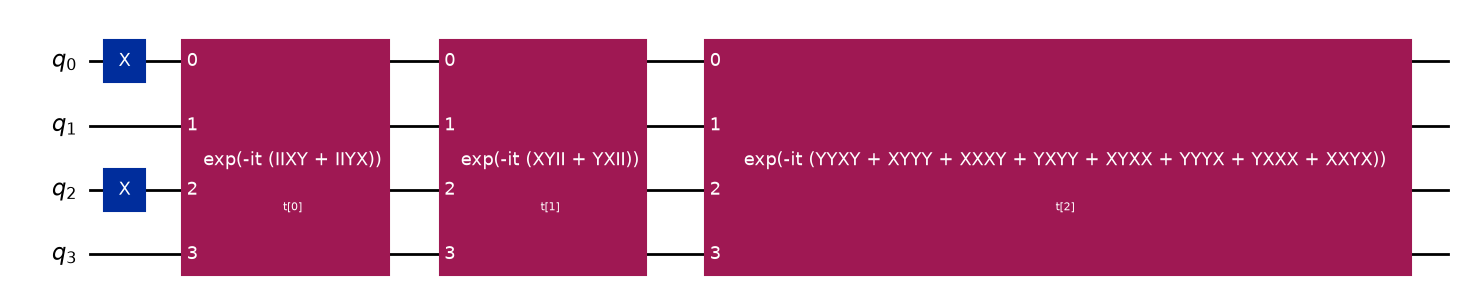

In [11]:
# Hartree–Fock State & UCC Ansatz

from qiskit_nature.second_q.circuit.library import HartreeFock, UCC
import matplotlib.pyplot as plt

# Extract molecular information
num_spatial_orbitals = problem.num_spatial_orbitals
num_particles = problem.num_particles

print("Orbitals:", num_spatial_orbitals)
print("Particles:", num_particles)

# Build Hartree–Fock initial state
initial_state = HartreeFock(
    num_spatial_orbitals=num_spatial_orbitals,
    num_particles=num_particles,
    qubit_mapper=mapper
)
print(initial_state)
# Build UCCSD Ansatz
ansatz = UCC(
    num_spatial_orbitals=num_spatial_orbitals,
    num_particles=num_particles,
    qubit_mapper=mapper,
    excitations="sd",
    initial_state=initial_state
)

# Display circuit
ansatz.decompose().draw("mpl")


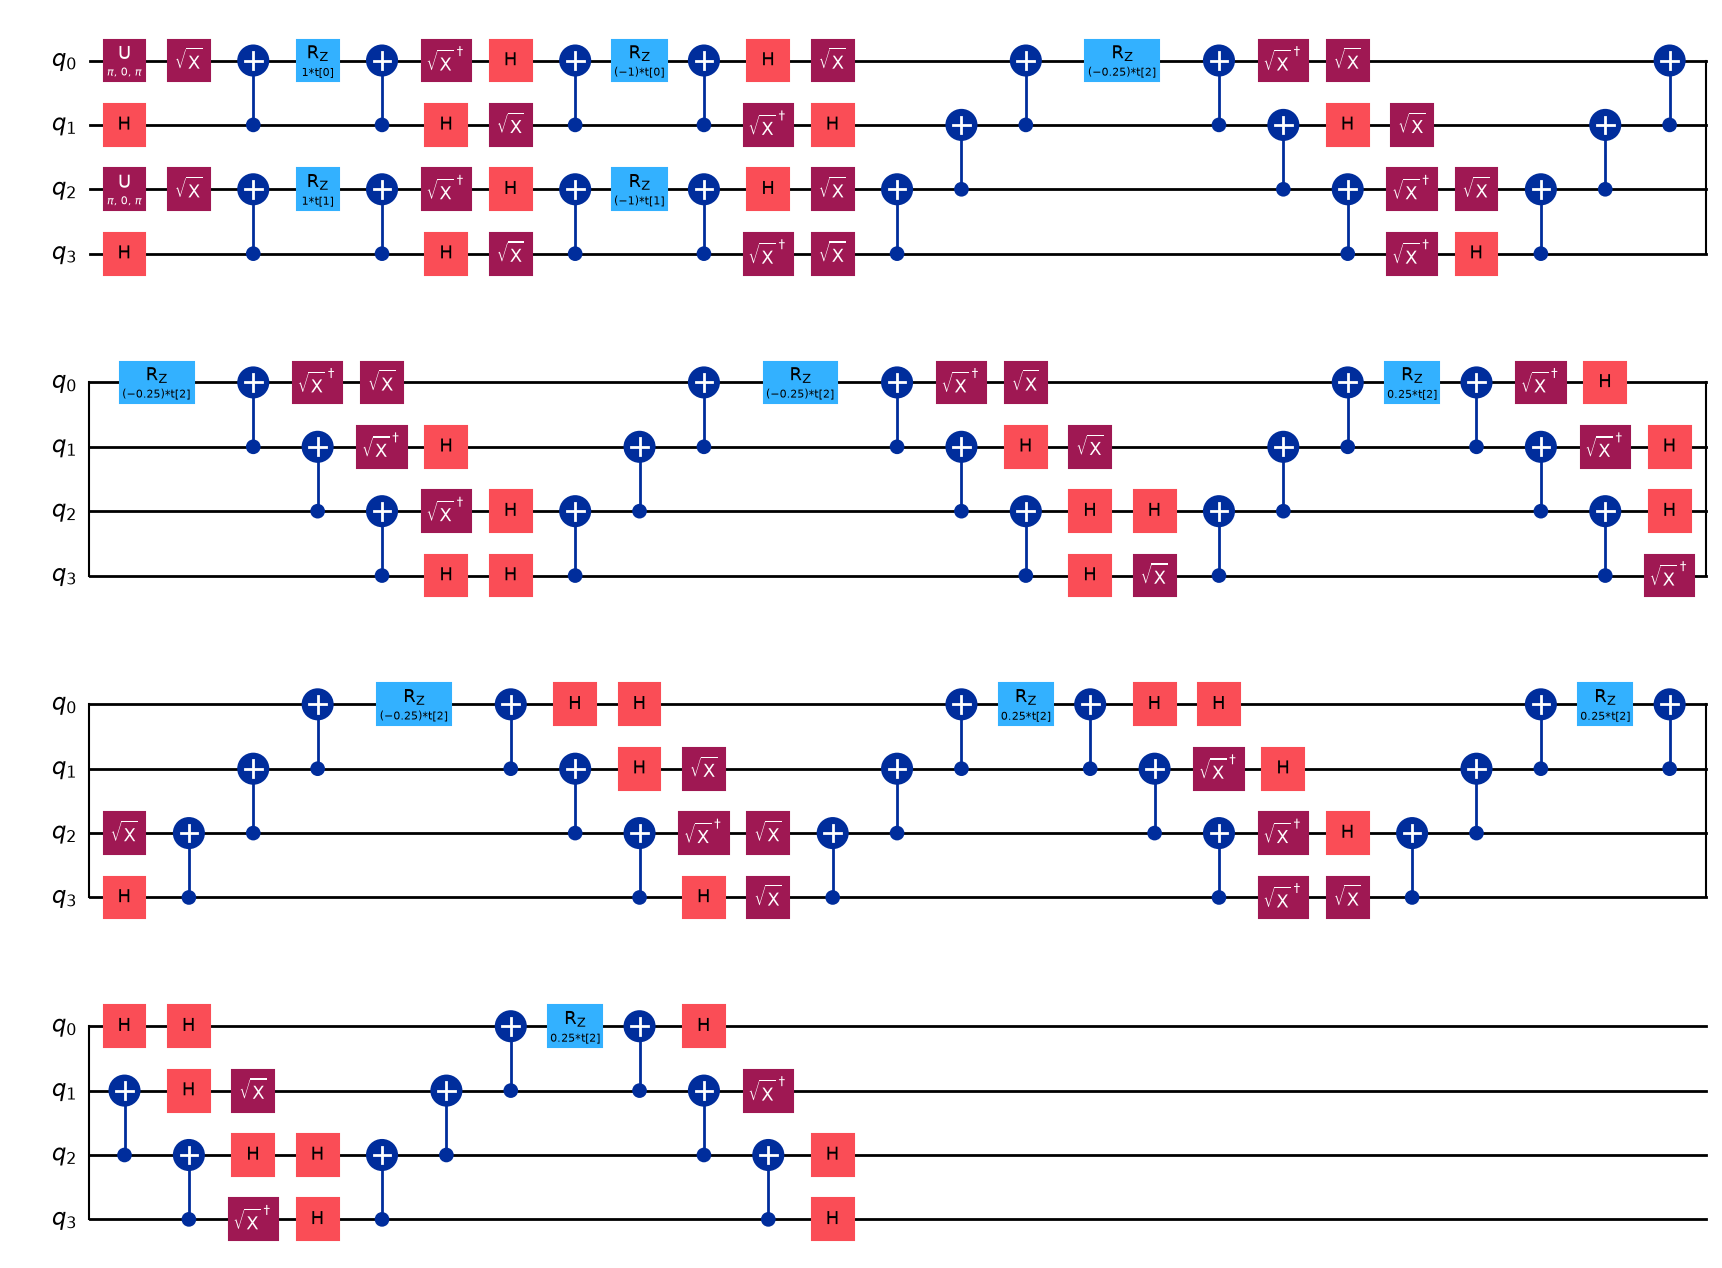

In [10]:
ansatz.decompose().decompose().draw("mpl")

## 5. VQE Optimization Loop

After preparing the variational quantum state using the Ansatz, the **Variational Quantum Eigensolver (VQE)** iteratively minimizes the molecular energy.

### Step-by-Step Loop Process

1. **State Preparation (Quantum):** For a given set of variational parameters:
   $$
   \theta = (\theta_1, \theta_2, \ldots, \theta_n)
   $$
   The quantum computer prepares the parameterized trial state:
   $$
   |\Psi(\theta)\rangle
   $$

2. **Energy Measurement (Quantum):** The quantum hardware evaluates the expectation value of the qubit Hamiltonian:
   $$
   E(\theta) = \langle \Psi(\theta) | \hat H | \Psi(\theta) \rangle
   $$
   This expectation value represents the estimated molecular energy for the current parameter set.

3. **Parameter Update (Classical):** The computed energy $E(\theta)$ is passed to a classical optimizer (running on a conventional computer), such as:
   * **COBYLA** (Constrained Optimization By Linear Approximations)
   * **SPSA** (Simultaneous Perturbation Stochastic Approximation)
   
   The optimizer processes the energy value and updates the parameters to search for a lower energy state:
   $$
   \theta \rightarrow \theta'
   $$

---

### The Hybrid Quantum-Classical Loop

The entire optimization loop can be represented schematically as:

$$
\theta \xrightarrow{\text{Quantum}} |\Psi(\theta)\rangle \xrightarrow{\text{Measurement}} \langle\hat H\rangle_\theta \xrightarrow{\text{Classical}} \text{Optimizer} \rightarrow \theta'
$$

This hybrid process repeats iteratively until the energy converges within a predefined threshold:
$$
\left| E(\theta^{(k+1)}) - E(\theta^{(k)}) \right| \approx 0
$$

At convergence:
$$
E(\theta^*) \approx E_0
$$
where:
* $E_0$ is the approximated ground-state energy of the molecule.
* $\theta^*$ represents the final optimized variational parameters.

/home/habiba/qc/lib/python3.12/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/habiba/qc/lib/python3.12/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


VQE Energy: -1.8572750268921419
Exact Energy: -1.8572750302023833


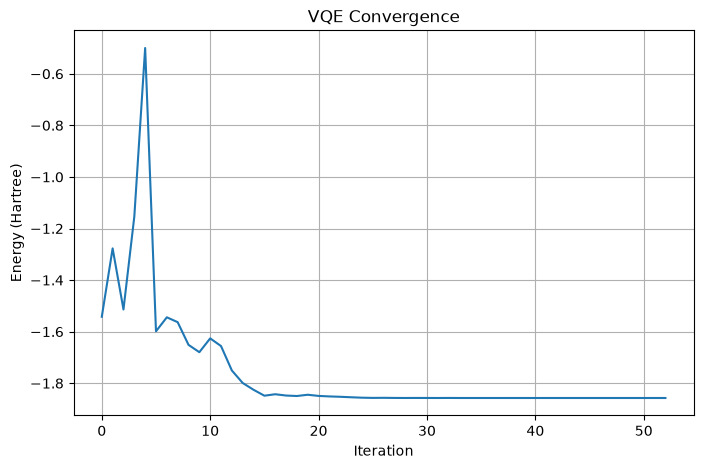

In [12]:
# VQE Optimization Loop

from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit_algorithms import NumPyMinimumEigensolver
import matplotlib.pyplot as plt

# Store energy values during optimization
energy_history = []

# Callback function
def callback(eval_count, params, energy, metadata):
    energy_history.append(energy)

# Quantum estimator
estimator = StatevectorEstimator()

# Classical optimizer
optimizer = COBYLA(maxiter=100)

# Build VQE
vqe = VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=optimizer,
    callback=callback
)

# Run optimization
result = vqe.compute_minimum_eigenvalue(
    operator=qubit_hamiltonian
)

# Extract energies
vqe_energy = result.eigenvalue.real

# Exact classical energy
exact_solver = NumPyMinimumEigensolver()
exact_result = exact_solver.compute_minimum_eigenvalue(
    qubit_hamiltonian
)

exact_energy = exact_result.eigenvalue.real

# Print results
print("VQE Energy:", vqe_energy)
print("Exact Energy:", exact_energy)

# Plot convergence
plt.figure(figsize=(8,5))
plt.plot(energy_history)

plt.xlabel("Iteration")
plt.ylabel("Energy (Hartree)")
plt.title("VQE Convergence")

plt.grid()

plt.show()

